# Activation Functions


## Problem Definition

**Activation functions break the linearity. They warp the output of each layer through a nonlinear function, giving the network the ability to bend decision boundaries, approximate arbitrary functions, and actually learn.**

## Basic Concepts

### Nonlineartiy

**Matrix multiplication is composable. Multiplying a vector by matrix A then matrix B is identical to multiplying by AB. This means stacking ten linear layers is mathematically equivalent to one linear layer with one big matrix. All those parameters, all that depth -- wasted. You need something to break the chain. That's what activation functions do.**

## Activation Functions

### Sigmoid

```
sigmoid(x) = 1 / (1 + e^(-x))
```

```
sigmoid'(x) = sigmoid(x) * (1 - sigmoid(x))
```

**Attributes**
* Output range: (0, 1). Smooth, differentiable, maps any real number to a probability-like value.
* The maximum value of this derivative is 0.25, causing Gradient vanishing.
* gradients on weights are always the same sign. This causes zig-zagging during gradient descent.

### Tanh
```
tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
```

```
tanh'(x) = 1 - tanh(x)^2
```

**Attributes**
* Maximum derivative is 1.0 at x = 0 -- four times better than sigmoid. But the vanishing gradient problem still exists.

### ReLU

```
relu(x) = max(0, x)
```

```
relu'(x) = 1  if x > 0
            0  if x <= 0
```
**Attributes**
* No vanishing gradient for positive inputs. The gradient is exactly 1, passed straight through. 
* The dead neuron problem. If a neuron's weighted input is always negative (due to a large negative bias or unfortunate weight initialization), its output is always zero, its gradient is always zero, and it never updates.

### Leaky ReLU

```
leaky_relu(x) = x        if x > 0
                alpha * x if x <= 0
```
**Attributes**
* Where alpha is a small constant, typically 0.01. The negative side has a small slope instead of zero, so dead neurons still get a gradient signal and can recover.

### GELU
**Default activation in BERT, GPT, and most modern transformers.**

```
gelu(x) = x * Phi(x)
```

Where Phi(x) is the cumulative distribution function of the standard normal distribution. The approximation used in practice:

```
gelu(x) ~= 0.5 * x * (1 + tanh(sqrt(2/pi) * (x + 0.044715 * x^3)))
```

GELU is smooth everywhere, allows small negative values (unlike ReLU which hard-clips to zero), and has a probabilistic interpretation: it weights each input by how likely it is to be positive under a Gaussian distribution. This smooth gating outperforms ReLU in transformer architectures because it provides better gradient flow and avoids the dead neuron problem entirely.

### SiLU

```
swish(x) = x * sigmoid(x)
```

**Swish uses sigmoid for gating while GELU uses the Gaussian CDF. In practice, performance is nearly identical. Swish is used in EfficientNet and some vision models. GELU dominates in language models.**

### Which Activation When

```mermaid
flowchart TD
    Start["What are you building?"] --> Hidden{"Hidden layers<br/>or output?"}

    Hidden -->|"Hidden layers"| Arch{"Architecture?"}
    Hidden -->|"Output layer"| Task{"Task type?"}

    Arch -->|"Transformer / NLP"| GELU["Use GELU"]
    Arch -->|"CNN / Vision"| ReLU["Use ReLU or Swish"]
    Arch -->|"RNN / LSTM"| Tanh["Use Tanh"]
    Arch -->|"Simple MLP"| ReLU2["Use ReLU"]

    Task -->|"Binary classification"| Sigmoid["Use Sigmoid"]
    Task -->|"Multi-class classification"| Softmax["Use Softmax"]
    Task -->|"Regression"| Linear["Use Linear (no activation)"]
```


# Build your Own

In [1]:
import math
import random


def sigmoid(x):
    x = max(-500, min(500, x))
    return 1.0 / (1.0 + math.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


def tanh_act(x):
    return math.tanh(x)


def tanh_derivative(x):
    t = math.tanh(x)
    return 1 - t * t


def relu(x):
    return max(0.0, x)


def relu_derivative(x):
    return 1.0 if x > 0 else 0.0


def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x


def leaky_relu_derivative(x, alpha=0.01):
    return 1.0 if x > 0 else alpha


def gelu(x):
    return 0.5 * x * (1 + math.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)))


def gelu_derivative(x):
    phi = 0.5 * (1 + math.erf(x / math.sqrt(2)))
    pdf = math.exp(-0.5 * x * x) / math.sqrt(2 * math.pi)
    return phi + x * pdf


def swish(x):
    return x * sigmoid(x)


def swish_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)


def softmax(xs):
    max_x = max(xs)
    exps = [math.exp(x - max_x) for x in xs]
    total = sum(exps)
    return [e / total for e in exps]


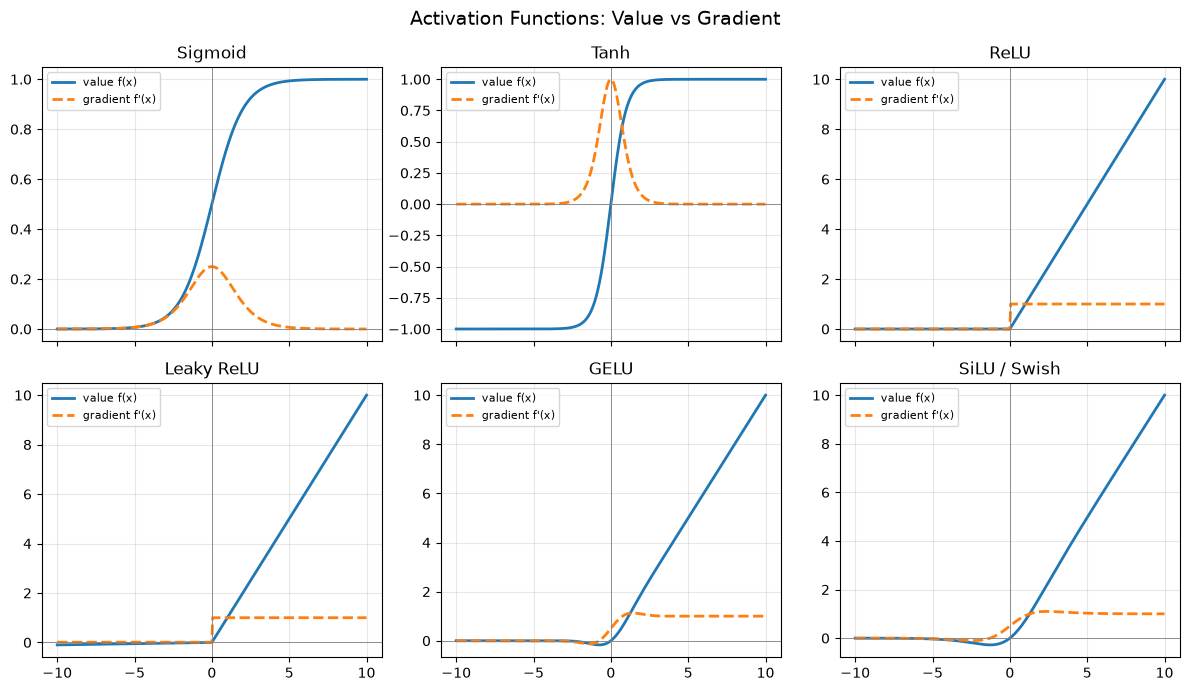

In [2]:
## Draw Value and Gradient for those Activation Functions
%matplotlib inline
import matplotlib.pyplot as plt

xs = [i * 0.05 for i in range(-120, 121)]  # [-6, 6]

activations = [
    ("Sigmoid", sigmoid, sigmoid_derivative),
    ("Tanh", tanh_act, tanh_derivative),
    ("ReLU", relu, relu_derivative),
    ("Leaky ReLU", leaky_relu, leaky_relu_derivative),
    ("GELU", gelu, gelu_derivative),
    ("SiLU / Swish", swish, swish_derivative),
]

fig, (ax_val, ax_grad) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for name, f, df in activations:
    ax_val.plot(xs, [f(x) for x in xs], linewidth=2, label=name)
    ax_grad.plot(xs, [df(x) for x in xs], linewidth=2, label=name)

for ax, title in ((ax_val, "Value f(x)"), (ax_grad, "Gradient f'(x)")):
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Activation Functions Comparison", fontsize=14)
plt.tight_layout()
plt.show()
